In [68]:
import random
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Códigos de conteúdo das células do grid
EMPTY = 0
DIRT = 1
OBSTACLE = 2


class VacuumEnvironment:
    """
    Ambiente de grade determinístico e parcialmente observável.
    O agente NÃO conhece de antemão o tamanho/limites do grid, a posição
    dos obstáculos nem a distribuição inicial de sujeira. A cada passo,
    ele só percebe: (1) se a célula em que está é suja e (2) se a última
    tentativa de movimento bateu em um obstáculo ou no limite do grid.
    """

    ACTIONS = ["Suck", "Up", "Down", "Left", "Right", "NoOp"]
    MOVES = {
        "Up": (-1, 0),
        "Down": (1, 0),
        "Left": (0, -1),
        "Right": (0, 1),
    }

    def __init__(self, rows, cols, dirt_cells, obstacle_cells, agent_pos):
        self.rows = rows
        self.cols = cols
        self.grid = np.full((rows, cols), EMPTY, dtype=int)
        for (r, c) in obstacle_cells:
            self.grid[r, c] = OBSTACLE
        for (r, c) in dirt_cells:
            if self.grid[r, c] != OBSTACLE:
                self.grid[r, c] = DIRT
        self.agent_pos = agent_pos
        self.bumped = False  # resultado da última tentativa de movimento

    def in_bounds(self, r, c):
        return 0 <= r < self.rows and 0 <= c < self.cols

    def percept(self):
        """Percepção local: sujeira na célula atual e se houve colisão."""
        r, c = self.agent_pos
        dirty = self.grid[r, c] == DIRT
        return {"dirty": dirty, "bump": self.bumped}

    def step(self, action):
        """
        Executa a ação do agente e atualiza o estado do ambiente.
        Retorna (moved, cleaned):
          moved   -> True se houve um movimento efetivo (custo de movimento)
          cleaned -> True se a ação limpou um quadrado que estava sujo
        """
        self.bumped = False
        moved = False
        cleaned = False
        r, c = self.agent_pos

        if action == "Suck":
            if self.grid[r, c] == DIRT:
                self.grid[r, c] = EMPTY
                cleaned = True
        elif action in self.MOVES:
            dr, dc = self.MOVES[action]
            nr, nc = r + dr, c + dc
            if self.in_bounds(nr, nc) and self.grid[nr, nc] != OBSTACLE:
                self.agent_pos = (nr, nc)
                moved = True
            else:
                self.bumped = True
        # NoOp: nenhuma alteração no ambiente

        return moved, cleaned

    def dirt_count(self):
        """Quantidade de quadrados ainda sujos."""
        return int(np.sum(self.grid == DIRT))

    def is_clean(self):
        """True quando não resta nenhum quadrado sujo."""
        return self.dirt_count() == 0

In [69]:
class SimpleReflexAgent:
    """
    Agente reativo simples (condição-ação).
    Decide a ação usando SOMENTE a percepção atual (sujeira, colisão),
    sem manter mapa ou histórico do ambiente. Ao colidir, escolhe uma
    nova direção aleatória; do contrário mantém a direção atual.
    """

    def __init__(self, seed=None):
        self.rng = random.Random(seed)
        self.direction = self.rng.choice(list(VacuumEnvironment.MOVES.keys()))

    def act(self, percept):
        # Regra 1: se a célula está suja, aspire
        if percept["dirty"]:
            return "Suck"
        # Regra 2: se bateu, escolha nova direção aleatória
        if percept["bump"]:
            self.direction = self.rng.choice(list(VacuumEnvironment.MOVES.keys()))
        # Regra 3: continue andando na direção atual
        return self.direction


class ModelBasedReflexAgent:
    """
    Agente reativo baseado em modelo.
    Mantém um modelo interno do ambiente: posição estimada (relativa ao
    ponto de partida, obtida por 'dead-reckoning' a partir das ações) e
    o estado conhecido de cada célula já visitada/detectada
    ('unknown', 'clean', 'dirty' ou 'obstacle'). Usa esse modelo para
    preferir explorar células desconhecidas ou sujas em vez de repetir
    células já limpas ou bater em obstáculos já conhecidos.
    """

    def __init__(self, seed=None):
        self.rng = random.Random(seed)
        self.pos = (0, 0)                    # posição estimada no referencial próprio
        self.known = {self.pos: "unknown"}   # modelo interno do mundo
        self.last_action = None

    def _update_model(self, percept):
        # Atualiza a posição estimada / registra obstáculos conforme o
        # resultado da última ação de movimento tentada
        if self.last_action in VacuumEnvironment.MOVES:
            dr, dc = VacuumEnvironment.MOVES[self.last_action]
            destino = (self.pos[0] + dr, self.pos[1] + dc)
            if percept["bump"]:
                self.known[destino] = "obstacle"
            else:
                self.pos = destino

        # Atualiza o estado conhecido da célula atual
        self.known[self.pos] = "dirty" if percept["dirty"] else "clean"

    def _choose_direction(self):
        """
        Prioriza mover para célula desconhecida > suja > limpa;
        NUNCA escolhe uma direção cujo destino já é um obstáculo conhecido.
        Retorna None se todas as direções vizinhas já forem obstáculos
        conhecidos (agente cercado): nesse caso não há movimento seguro.
        """
        candidatos = []
        for direcao, (dr, dc) in VacuumEnvironment.MOVES.items():
            destino = (self.pos[0] + dr, self.pos[1] + dc)
            estado = self.known.get(destino, "unknown")
            if estado == "obstacle":
                continue  # exclui explicitamente destinos já sabidos bloqueados
            prioridade = {"unknown": 0, "dirty": 1, "clean": 2}[estado]
            candidatos.append((prioridade, direcao))

        if not candidatos:
            # Cercado por obstáculos/limites conhecidos em todas as direções:
            # não existe ação de movimento que não repita uma colisão.
            return None

        melhor_prioridade = min(candidatos, key=lambda x: x[0])[0]
        melhores = [d for p, d in candidatos if p == melhor_prioridade]
        return self.rng.choice(melhores)

    def act(self, percept):
        self._update_model(percept)

        if percept["dirty"]:
            acao = "Suck"
        else:
            direcao = self._choose_direction()
            # Se estiver cercado por obstáculos conhecidos, não tenta se
            # mover (evitaria repetir uma colisão já conhecida): faz NoOp.
            acao = direcao if direcao is not None else "NoOp"

        self.last_action = acao
        return acao

In [70]:
def run_simulation(env, agent, max_steps=500):
    """
    Executa a simulação até o ambiente ficar totalmente limpo ou até
    'max_steps' passos (o que ocorrer primeiro).

    Métricas (cada quadrado sujo só pode render 1 ponto, uma única vez):
      M1: +1 por quadrado limpo pelo agente.
      M2: +1 por quadrado limpo pelo agente e -1 por movimento realizado.

    Como o ambiente é determinístico e a trajetória do agente não depende
    da métrica, M1 e M2 são calculadas na mesma execução.
    """
    quadrados_limpos = 0
    movimentos = 0
    passos = 0

    # Para assim que não houver mais sujeira (ou ao atingir o limite de passos)
    while passos < max_steps and not env.is_clean():
        percept = env.percept()
        action = agent.act(percept)
        moved, cleaned = env.step(action)

        passos += 1
        if moved:
            movimentos += 1
        if cleaned:
            quadrados_limpos += 1

    return {
        "M1": quadrados_limpos,
        "M2": quadrados_limpos - movimentos,
        "passos": passos,
        "movimentos": movimentos,
        "limpou_tudo": env.is_clean(),
    }

In [71]:
def reachable_cells(rows, cols, obstacle_cells, start):
    """Células alcançáveis a partir de 'start' (BFS), respeitando obstáculos."""
    obstaculos = set(obstacle_cells)
    visitadas = {start}
    fila = deque([start])
    while fila:
        r, c = fila.popleft()
        for dr, dc in VacuumEnvironment.MOVES.values():
            nr, nc = r + dr, c + dc
            if (0 <= nr < rows and 0 <= nc < cols
                    and (nr, nc) not in obstaculos and (nr, nc) not in visitadas):
                visitadas.add((nr, nc))
                fila.append((nr, nc))
    return visitadas


def generate_configs(rows, cols, n_configs, dirt_ratio=0.4, obstacle_ratio=0.15, seed=0):
    """
    Gera várias configurações iniciais (sujeira, obstáculos, posição do agente).
    A sujeira é sempre colocada apenas em células alcançáveis pelo agente,
    garantindo que o ambiente possa ser totalmente limpo.
    """
    rng = random.Random(seed)
    todas_as_celulas = [(r, c) for r in range(rows) for c in range(cols)]
    configs = []

    for _ in range(n_configs):
        celulas = todas_as_celulas.copy()
        rng.shuffle(celulas)

        n_obs = int(len(celulas) * obstacle_ratio)
        obstacle_cells = celulas[:n_obs]
        agent_pos = celulas[n_obs]  # primeira célula livre

        alcancaveis = sorted(reachable_cells(rows, cols, obstacle_cells, agent_pos))
        n_dirt = max(1, int(len(alcancaveis) * dirt_ratio))
        dirt_cells = rng.sample(alcancaveis, n_dirt)

        configs.append({
            "dirt_cells": dirt_cells,
            "obstacle_cells": obstacle_cells,
            "agent_pos": agent_pos,
        })
    return configs


# Parâmetros fixos do experimento
ROWS, COLS = 8, 8
N_CONFIGS = 10
MAX_STEPS = 500

configs = generate_configs(ROWS, COLS, N_CONFIGS, seed=42)

agent_types = {
    "Reflexo Simples": SimpleReflexAgent,
    "Reflexo com Modelo": ModelBasedReflexAgent,
}

resultados = []
for cfg_idx, cfg in enumerate(configs):
    for agent_name, AgentClass in agent_types.items():
        # Cada agente recebe uma cópia nova do ambiente inicial
        env = VacuumEnvironment(
            ROWS, COLS,
            cfg["dirt_cells"], cfg["obstacle_cells"], cfg["agent_pos"],
        )
        agent = AgentClass(seed=cfg_idx)
        res = run_simulation(env, agent, max_steps=MAX_STEPS)
        resultados.append({
            "config": cfg_idx,
            "agente": agent_name,
            "sujeira_inicial": len(cfg["dirt_cells"]),
            "M1": res["M1"],
            "M2": res["M2"],
            "passos": res["passos"],
            "movimentos": res["movimentos"],
            "limpou_tudo": res["limpou_tudo"],
        })

df = pd.DataFrame(resultados)
df

,config,agente,sujeira_inicial,M1,M2,passos,movimentos,limpou_tudo
0,0,Reflexo Simples,22,12,-351,500,363,False
1,0,Reflexo com Modelo,22,21,-426,500,447,False
2,1,Reflexo Simples,22,13,-348,500,361,False
3,1,Reflexo com Modelo,22,22,-237,311,259,True
4,2,Reflexo Simples,22,18,-308,500,326,False
5,2,Reflexo com Modelo,22,22,-120,191,142,True
6,3,Reflexo Simples,22,19,-310,500,329,False
7,3,Reflexo com Modelo,22,22,-275,350,297,True
8,4,Reflexo Simples,22,18,-275,500,293,False
9,4,Reflexo com Modelo,22,21,-426,500,447,False


M1                                 M2                   
agente Reflexo Simples Reflexo com Modelo Reflexo Simples Reflexo com Modelo
config                                                                      
0                 12.0               21.0          -351.0             -426.0
1                 13.0               22.0          -348.0             -237.0
2                 18.0               22.0          -308.0             -120.0
3                 19.0               22.0          -310.0             -275.0
4                 18.0               21.0          -275.0             -426.0
5                 18.0               22.0          -299.0             -168.0
6                  7.0               22.0          -295.0             -221.0
7                 15.0               22.0          -280.0              -63.0
8                 11.0               22.0          -352.0             -101.0
9                 12.0               22.0          -341.0             -280.0

,agente,M1_media,M2_media,passos_medios,movimentos_medios,taxa_limpeza_total
0,Reflexo Simples,14.3,-315.9,500.0,330.2,0.0
1,Reflexo com Modelo,21.8,-231.7,305.0,253.5,0.8


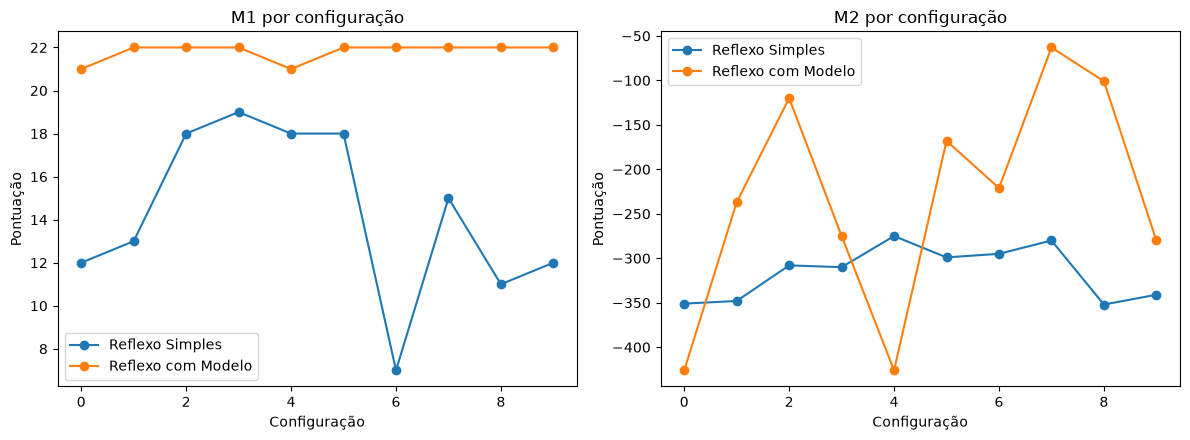

In [72]:
# Tabela: pontuação M1 e M2 por configuração e agente
tabela = df.pivot_table(index="config", columns="agente", values=["M1", "M2"])
display(tabela)

# Tabela: média global por agente
media_global = (
    df.groupby("agente")
    .agg(
        M1_media=("M1", "mean"),
        M2_media=("M2", "mean"),
        passos_medios=("passos", "mean"),
        movimentos_medios=("movimentos", "mean"),
        taxa_limpeza_total=("limpou_tudo", "mean"),
    )
    .reset_index()
)
display(media_global)

# pontuação por configuração (uma linha por agente, um painel por métrica)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
for ax, metrica in zip(axes, ["M1", "M2"]):
    for agente, grupo in df.groupby("agente"):
        serie = grupo.set_index("config")[metrica].sort_index()
        ax.plot(serie.index, serie.values, marker="o", label=agente)
    ax.set_xlabel("Configuração")
    ax.set_ylabel("Pontuação")
    ax.set_title(f"{metrica} por configuração")
    ax.legend()
plt.tight_layout()
plt.show()

## Graficos de barra adicionais

As celulas abaixo reaproveitam a tabela `df` calculada anteriormente e cobrem todos os atributos coletados no experimento: M1, M2, sujeira restante, passos, movimentos e taxa de limpeza total.

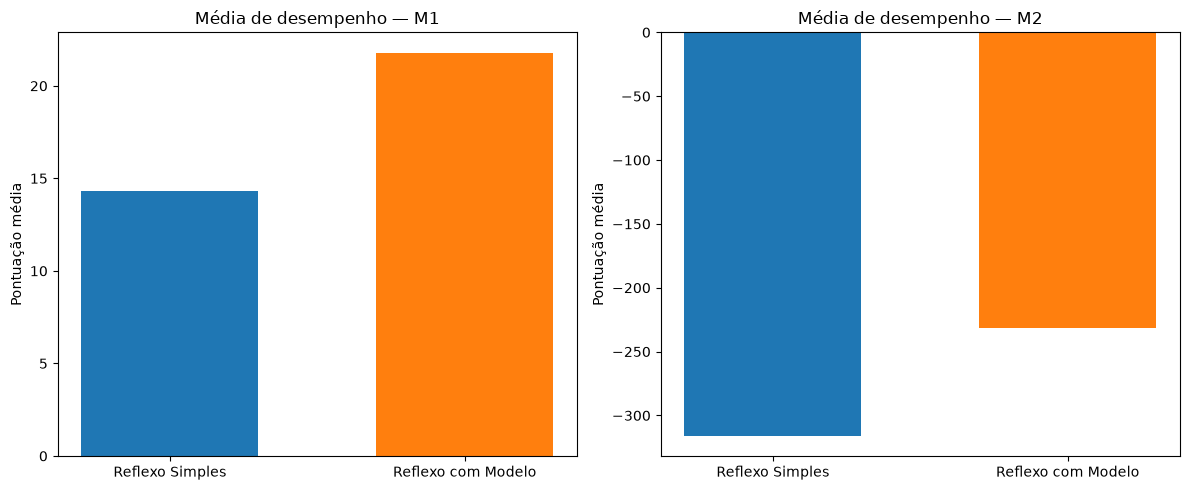

In [73]:
media_metricas = df.groupby("agente")[["M1", "M2"]].mean()

x = np.arange(len(media_metricas.index))
largura = 0.6

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Cores dos agentes
cores = ["#1f77b4", "#ff7f0e"]

# Gráfico M1
axes[0].bar(
    x,
    media_metricas["M1"],
    largura,
    color=cores
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(media_metricas.index)
axes[0].set_ylabel("Pontuação média")
axes[0].set_title("Média de desempenho — M1")

# Gráfico M2
axes[1].bar(
    x,
    media_metricas["M2"],
    largura,
    color=cores
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(media_metricas.index)
axes[1].set_ylabel("Pontuação média")
axes[1].set_title("Média de desempenho — M2")

plt.tight_layout()
plt.show()

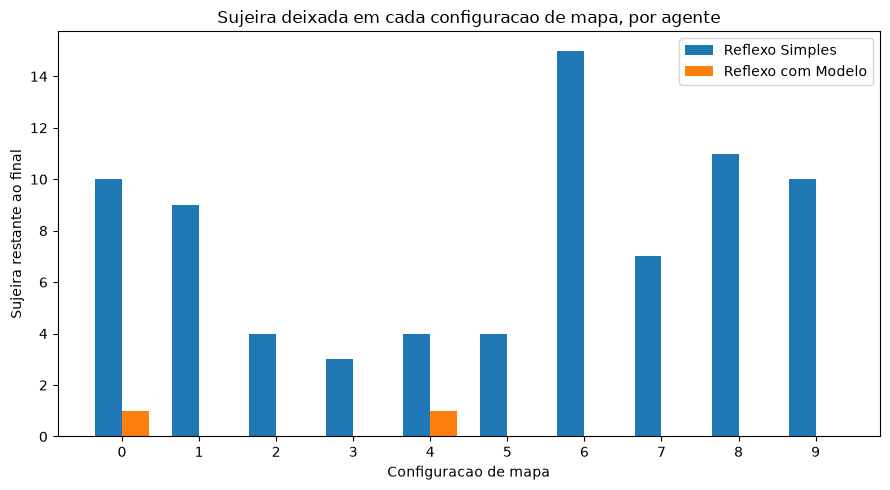

In [74]:
# Grafico B: sujeira restante ao final, por configuracao de mapa e agente
# Cada quadrado sujo so pode ser limpo uma vez, entao sujeira restante = sujeira inicial - M1
df["sujeira_restante"] = df["sujeira_inicial"] - df["M1"]
sujeira_pivot = df.pivot(index="config", columns="agente", values="sujeira_restante")

x = np.arange(len(sujeira_pivot.index))
largura = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
for i, agente in enumerate(sujeira_pivot.columns):
    ax.bar(x + (i - 0.5) * largura, sujeira_pivot[agente], largura, label=agente)
ax.set_xticks(x)
ax.set_xticklabels(sujeira_pivot.index)
ax.set_xlabel("Configuracao de mapa")
ax.set_ylabel("Sujeira restante ao final")
ax.set_title("Sujeira deixada em cada configuracao de mapa, por agente")
ax.legend()
plt.tight_layout()
plt.show()


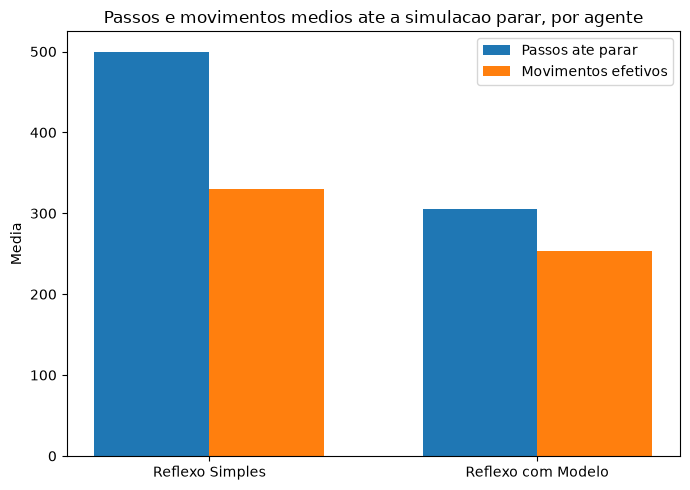

In [75]:
# Grafico D: passos ate parar e movimentos efetivos, por agente
resumo_esforco = df.groupby("agente")[["passos", "movimentos"]].mean()

x = np.arange(len(resumo_esforco.index))
largura = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - largura / 2, resumo_esforco["passos"], largura, label="Passos ate parar")
ax.bar(x + largura / 2, resumo_esforco["movimentos"], largura, label="Movimentos efetivos")
ax.set_xticks(x)
ax.set_xticklabels(resumo_esforco.index)
ax.set_ylabel("Media")
ax.set_title("Passos e movimentos medios ate a simulacao parar, por agente")
ax.legend()
plt.tight_layout()
plt.show()


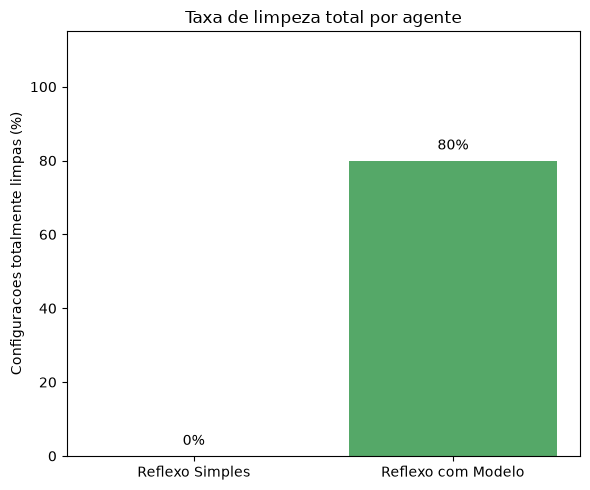

In [76]:
# Grafico E: taxa de limpeza total (mapas totalmente limpos), por agente
taxa = df.groupby("agente")["limpou_tudo"].mean() * 100

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(taxa.index, taxa.values, color=["#C44E52", "#55A868"])
ax.set_ylabel("Configuracoes totalmente limpas (%)")
ax.set_title("Taxa de limpeza total por agente")
ax.set_ylim(0, 115)
for i, v in enumerate(taxa.values):
    ax.text(i, v + 3, f"{v:.0f}%", ha="center")
plt.tight_layout()
plt.show()
